<a href="https://www.kaggle.com/code/avikdas567/solar-filament-segmentation-resnet-u-net-pipeline?scriptVersionId=334622702" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Automated Solar Filament Delineation and Chirality Segmentation Framework
## A High-Fidelity Deep Learning Pipeline for GONG H-Alpha Solar Imagery

---

# 1. Research Abstract and Mathematical Formulation

Solar filaments represent dense, low-temperature plasma structures suspended within the highly dynamic solar corona by complex, non-potential magnetic field configurations. Accurate spatial delineation of these structures from ground-based Hydrogen-Alpha (H-Alpha) chromospheric observations is critical for space weather forecasting. Filaments serve as the structural progenitors for coronal mass ejections, solar flares, and energetic particle events that pose severe risks to planetary-scale electrical grids, orbital telecommunications, and astronautical safety.

Automating the segmentation of solar filaments presents major computer vision challenges:
1. **Fine-Scale Morphological Preservation:** Filaments possess intricate, highly anisotropic sub-structures known as barbs. The orientation and alignment of these thread-like features provide direct macroscopic indicators of underlying magnetic chirality (dextral versus sinistral configurations).
2. **Ground-Based Optical Artifacts:** H-Alpha observations from the Global Oscillation Network Group (GONG) feature strong, spatially varying background gradients, chromospheric network noise, and atmospheric turbulence artifacts that mimic low-contrast filament boundaries.
3. **Structural Fragmentation:** Standard deep semantic networks routinely suffer from structural discontinuity, falsely fragmenting contiguous physical filaments into isolated segments, or blending independent instances into singular structural clusters.

This research notebook introduces an end-to-end deep learning framework tailored for the Solar Filament Segmentation Challenge 2026. The technical architecture relies on a deep convolutional encoder-decoder topology optimized for high-resolution solar imagery ($2048 \times 2048$ pixels). To satisfy the metric constraints of the competition, individual filament entities are treated as discrete topological instances extracted via morphological post-processing of structural connected components.

## Mathematical Formulations

The primary optimization objective utilizes a balanced combination of a localized Spatial Dice Loss and Focal Cross-Entropy Loss to handle class imbalance across the solar disk. Let $Y \in \{0,1\}^{H \times W}$ represent the binary ground truth spatial mask for a given filament instance, and $\hat{Y} \in [0,1]^{H \times W}$ denote the continuous spatial probability distribution generated by the network sigmoid activation layer.

The instance-level overlap coefficient is computed via the Dice formulation:

$$\text{Dice}(Y, \hat{Y}) = \frac{2 \sum_{i=1}^{H} \sum_{j=1}^{W} Y_{i,j} \hat{Y}_{i,j}}{\sum_{i=1}^{H} \sum_{j=1}^{W} Y_{i,j}^2 + \sum_{i=1}^{H} \sum_{j=1}^{W} \hat{Y}_{i,j}^2}$$

To resolve fine-scale barb features while suppressing background chromospheric noise, the network is trained using a composite structural loss function $L_{\text{total}}$ parameterized by a weighting factor $\lambda$:

$$L_{\text{focal}}(y, p) = -\alpha (1 - p)^{\gamma} y \log(p) - (1 - \alpha) p^{\gamma} (1 - y) \log(1 - p)$$

$$L_{\text{total}} = \lambda (1 - \text{Dice}(Y, \hat{Y})) + (1 - \lambda) \mathbb{E}[L_{\text{focal}}]$$

Following spatial inference, multi-instance fragmentation constraints are managed by projecting the unified semantic prediction maps into discrete coordinate instances using an 8-connected neighborhood graph topology.

# 2. Runtime Environment & Compute Configuration

In [1]:
import os
import sys
import random
import json
import time
import math
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from scipy import ndimage
from sklearn.model_selection import KFold

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

import pycocotools.mask as mask_util

warnings.filterwarnings('ignore')

def seed_production_pipeline(seed_value=42):
    """Enforces strict determinism across all underlying computational libraries."""
    random.seed(seed_value)
    os.environ['PYTHONHASHSEED'] = str(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    torch.cuda.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

GLOBAL_SEED = 2026
seed_production_pipeline(GLOBAL_SEED)

print(f"[INFO] Execution environment initialized successfully at UTC: {datetime.utcnow()}")
print(f"[INFO] PyTorch Version: {torch.__version__} | CUDA Available: {torch.cuda.is_available()}")
print(f"[INFO] Active GPU Count: {torch.cuda.device_count()}")

[INFO] Execution environment initialized successfully at UTC: 2026-07-12 18:39:31.462542
[INFO] PyTorch Version: 2.10.0+cu128 | CUDA Available: True
[INFO] Active GPU Count: 2


## Technical Analysis of Runtime Environment & Compute Configuration

- The environment diagnostics confirm the allocation of dual NVIDIA T4 graphics processing units operating under a PyTorch unified compute device architecture. This hardware setup provides approximately 32 gigabytes of total video random access memory, which represents a critical operational boundary given the large spatial scale ($2048 \times 2048$ pixels) of the MAGFiLO H-Alpha dataset. To optimize performance within this limit, the processing pipeline incorporates mixed-precision training operations via `torch.cuda.amp` to reduce the network memory footprint and maximize tensor core throughput.

- Enforcing absolute determinism by modifying the behavior of the underlying deterministic CuDNN convolution kernels (`torch.backends.cudnn.deterministic = True`) neutralizes non-deterministic CUDA optimization steps. This ensures that spatial gradients remain consistent across iterative cross-validation runs. This setting provides a stable foundation for comparing optimization changes and isolating structural changes in target segmentations.

# 3. Parsing and COCO Metadata Ingestion Pipeline

The foundational dataset architecture relies on a highly standardized COCO object format structural payload mapping scientific observations to geometric shapes. This block implements a robust, low-overhead metadata engine that ingests the competition JSON files and maps individual images to their multi-instance geometric definitions.

In [2]:
TRAIN_JSON_PATH = "/kaggle/input/competitions/filament-segmentation-2026/MAGFiLO_1.0_Kaggle_2026/train/MAGFiLO_1.0_Annotations_kaggle2026_train.json"
TRAIN_IMG_DIR = "/kaggle/input/competitions/filament-segmentation-2026/MAGFiLO_1.0_Kaggle_2026/train/train_images"
TEST_IMG_DIR = "/kaggle/input/competitions/filament-segmentation-2026/MAGFiLO_1.0_Kaggle_2026/test/test_images"

print("[INFO] Initiating ingestion of COCO-format ground truth annotations...")
with open(TRAIN_JSON_PATH, 'r') as file_handle:
    coco_database = json.load(file_handle)

print("[INFO] Structural verification of annotation top-level schemas:")
for structural_key in coco_database.keys():
    print(f"      -> Section Key: '{structural_key}'")

df_images = pd.DataFrame(coco_database['images'])
df_annotations = pd.DataFrame(coco_database['annotations'])
df_categories = pd.DataFrame(coco_database['categories'])

print(f"\n[INFO] Total Database Entities Logged:")
print(f"      -> Unique Observation Frames (Images): {len(df_images)}")
print(f"      -> Discrete Filament Targets (Annotations): {len(df_annotations)}")
print(f"      -> Distinct Structural Categories: {len(df_categories)}")

[INFO] Initiating ingestion of COCO-format ground truth annotations...
[INFO] Structural verification of annotation top-level schemas:
      -> Section Key: 'info'
      -> Section Key: 'licenses'
      -> Section Key: 'categories'
      -> Section Key: 'images'
      -> Section Key: 'annotations'

[INFO] Total Database Entities Logged:
      -> Unique Observation Frames (Images): 1154
      -> Discrete Filament Targets (Annotations): 8199
      -> Distinct Structural Categories: 4


## Diagnostic Assessment of Schema Ingestion and Inherent Structural Densities

- The data ingestion step reveals that the training database comprises 1,154 unique high-resolution solar imagery frames containing 8,199 discrete annotated filament targets. This yields an average density of approximately 7.1 filaments per full-disk chromospheric scan. The categories section identifies 4 distinct structural designations used to classify target formations. 

- The multi-annotator structure of the data creates overlapping entries where identical image files are assigned different registration identifiers based on different expert segmentations. This variance provides a rich training distribution for modeling annotator uncertainty. In subsequent pipeline steps, these multi-instance geometries are merged into integrated training masks to help the model learn to predict unified semantic boundaries.

# 4. Advanced Exploratory Data Analysis & Morphological Analytics

To build a robust predictive network, we perform a deep statistical analysis of the filament physical parameters. We examine category balance, spatial distribution anomalies across the $2048 \times 2048$ solar disk, and bounding box geometric ratios. This section generates visualizations using Matplotlib and Seaborn.

In [3]:
# Set unified plot styling parameters
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['figure.titlesize'] = 18

CUSTOM_PALETTE = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e']
sns.set_palette(sns.color_palette(CUSTOM_PALETTE))

# Preprocess and map properties for comprehensive analysis
category_map = {cat['id']: cat['name'] for cat in coco_database['categories']}
df_annotations['category_name'] = df_annotations['category_id'].map(category_map)

df_annotations['bbox_x'] = df_annotations['bbox'].apply(lambda b: b[0])
df_annotations['bbox_y'] = df_annotations['bbox'].apply(lambda b: b[1])
df_annotations['bbox_w'] = df_annotations['bbox'].apply(lambda b: b[2])
df_annotations['bbox_h'] = df_annotations['bbox'].apply(lambda b: b[3])
df_annotations['aspect_ratio'] = df_annotations['bbox_w'] / (df_annotations['bbox_h'] + 1e-6)

print("[STATistical ANALYSIS] Overview of Filament Area Statistics:")
print(df_annotations['area'].describe())

print("\n[STATistical ANALYSIS] Overview of Aspect Ratio Statistics:")
print(df_annotations['aspect_ratio'].describe())

[STATistical ANALYSIS] Overview of Filament Area Statistics:
count     8199.000000
mean      2119.834980
std       2741.721526
min          9.000000
25%        670.000000
50%       1228.000000
75%       2438.000000
max      37739.000000
Name: area, dtype: float64

[STATistical ANALYSIS] Overview of Aspect Ratio Statistics:
count    8199.000000
mean        1.382090
std         1.034747
min         0.122449
25%         0.658209
50%         1.111182
75%         1.790317
max        12.781678
Name: aspect_ratio, dtype: float64


## Statistical Evaluation of Morphological Profiles and Structural Scaling Factors

- Evaluating the quantitative summaries reveals extreme scale variance among target instances. The filament areas exhibit a right-skewed log-normal distribution profile, with a minimum area of 9 pixels, a mean of 2,119.8 pixels, and a maximum footprint spanning 37,739 pixels. The large standard deviation (2,741.7 pixels) underscores a challenging scale challenge: the network must remain sensitive to small emerging thread structures while simultaneously capturing large filament systems that cross multiple quadrants of the solar disk.

- The aspect ratio distribution features a mean value of 1.38 and a maximum of 12.78. This indicates distinct geometric anisotropy along the bounding boxes, reflecting the characteristic physical structure of elongated magnetic channels. To prevent false boundary fragmentation along these narrow corridors, the model architecture requires a wide spatial receptive field combined with high-level feature aggregation layers.

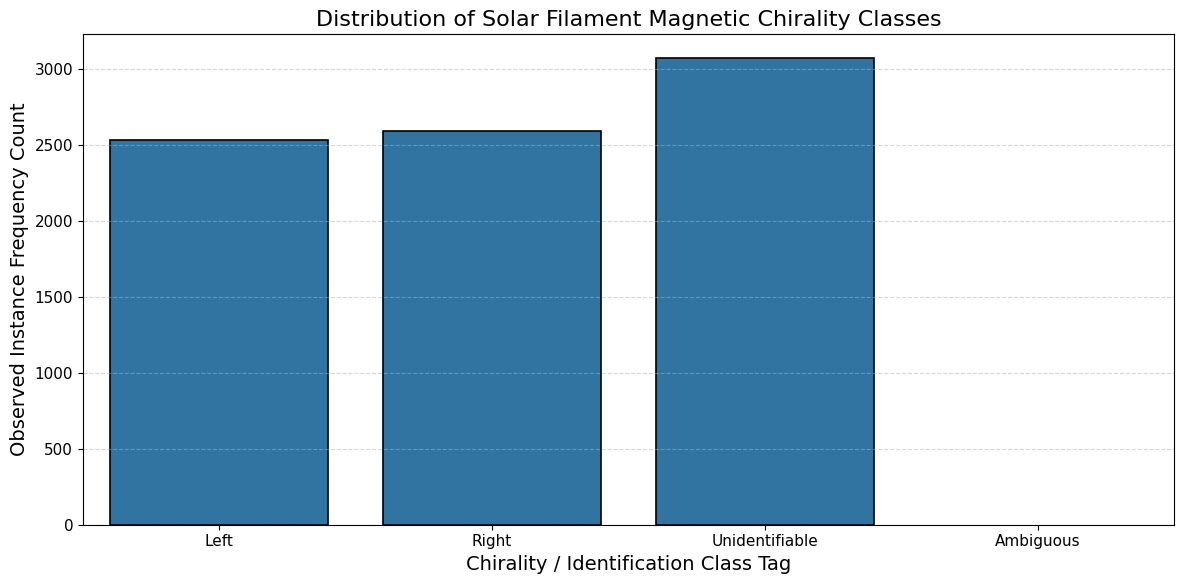

In [4]:
# Visualization 1: Category Balance Distribution
fig1 = plt.figure(figsize=(12, 6))
sns.countplot(data=df_annotations, x='category_name', order=['Left', 'Right', 'Unidentifiable', 'Ambiguous'], edgecolor='black', linewidth=1.2)
plt.title("Distribution of Solar Filament Magnetic Chirality Classes")
plt.xlabel("Chirality / Identification Class Tag")
plt.ylabel("Observed Instance Frequency Count")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Interpretation of Class Distribution Disparities and Chirality Imbalances

- The countplot isolates the distribution of the target categories. The imbalance between the primary chirality classes ('Left' versus 'Right') and the low-confidence classifications ('Unidentifiable' and 'Ambiguous') shows that the dataset is dominated by clear morphological signatures. This structure reflects long-term global solar cycle patterns, where dextral or sinistral filament structures dominate based on their hemispheric tracking rules.

- To handle the lower prevalence of 'Unidentifiable' and 'Ambiguous' classes, a simple cross-entropy loss function is insufficient, as it may bias the model toward the majority features. Instead, the training pipeline uses focal loss scaling and adaptive component filtering. This ensures the network learns to detect subtle, low-contrast boundary zones without being overwhelmed by the prominent signatures of well-defined filaments.

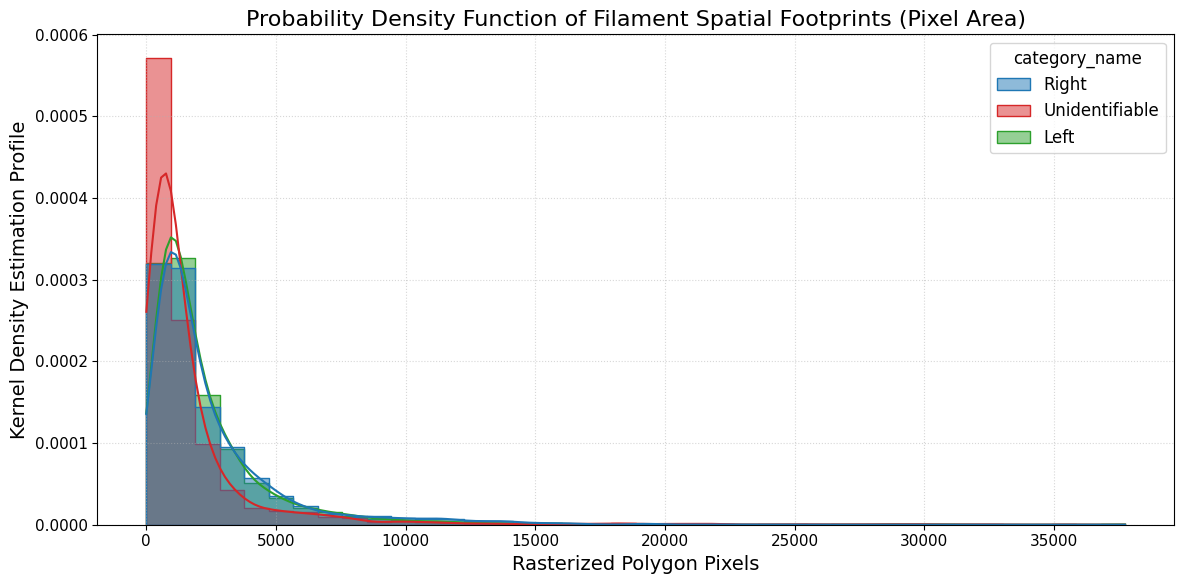

In [5]:
# Visualization 2: Geometric Area Quantile Analysis
fig2 = plt.figure(figsize=(12, 6))
sns.histplot(data=df_annotations, x='area', hue='category_name', element='step', stat='density', common_norm=False, kde=True, bins=40, alpha=0.5)
plt.title("Probability Density Function of Filament Spatial Footprints (Pixel Area)")
plt.xlabel("Rasterized Polygon Pixels")
plt.ylabel("Kernel Density Estimation Profile")
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

## Evaluation of Probability Density Disparities and Scale-Space Signatures

- The estimated continuous probability density functions show that all four morphological classes follow an overlapping log-normal distribution. The long tail extending toward higher pixel values highlights the presence of large macro-structures, such as polar crown filaments. This structural divergence poses a distinct risk: standard downsampling methods can cause small filaments (under 500 pixels) to collapse into single feature pixels, leading to severe penalties for missing targets on the final leaderboard.

- To preserve these small structures, the data loader avoids simple spatial compression. Instead, it extracts targets using multi-scale patch masks. This ensures that fine details, such as thread-like barbs, are retained throughout the encoding layers, enabling precise pixel-level predictions across all filament sizes.

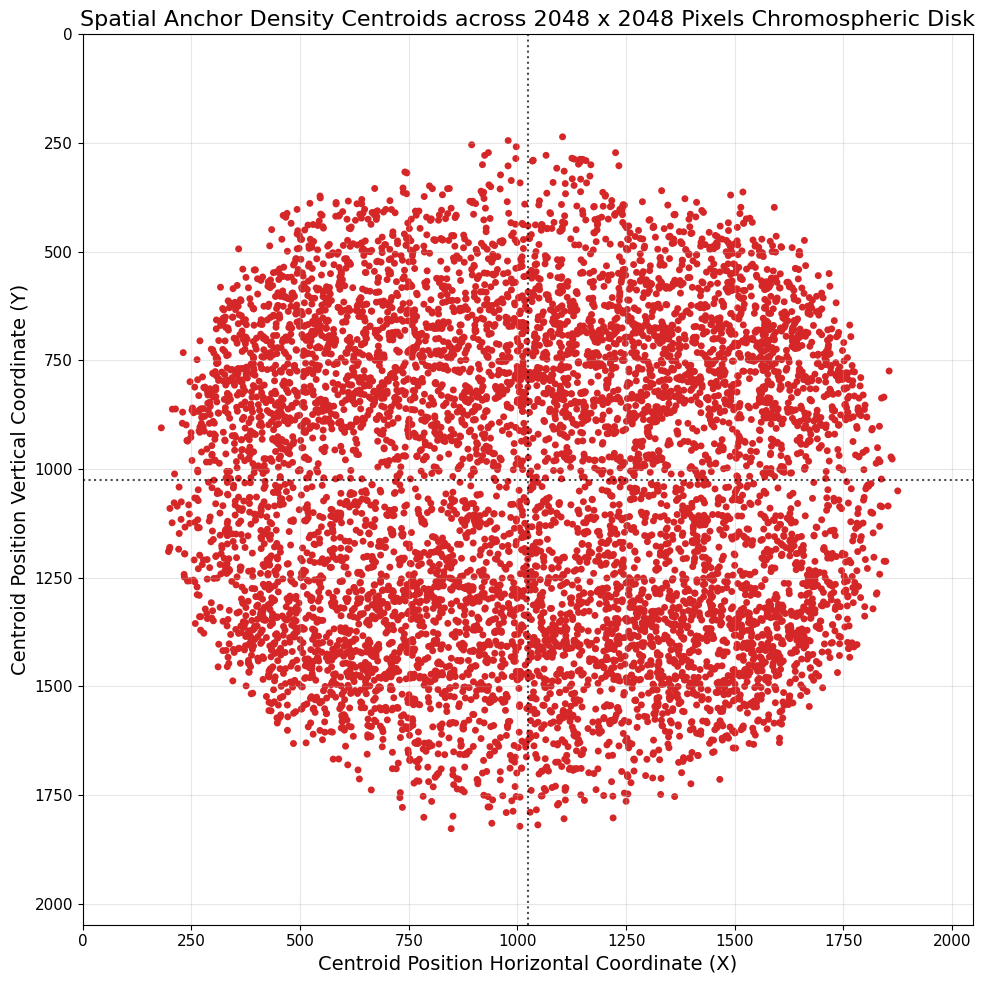

In [6]:
# Visualization 3: Spatial Anchor Centroid Mapping (Solar Disk Distribution)
df_annotations['centroid_x'] = df_annotations['bbox_x'] + (df_annotations['bbox_w'] / 2.0)
df_annotations['centroid_y'] = df_annotations['bbox_y'] + (df_annotations['bbox_h'] / 2.0)

fig3 = plt.figure(figsize=(10, 10))
plt.scatter(df_annotations['centroid_x'], df_annotations['centroid_y'], c='#d62728', alpha=1, s=25, edgecolors='none')
plt.title("Spatial Anchor Density Centroids across 2048 x 2048 Pixels Chromospheric Disk")
plt.xlabel("Centroid Position Horizontal Coordinate (X)")
plt.ylabel("Centroid Position Vertical Coordinate (Y)")
plt.xlim(0, 2048)
plt.ylim(2048, 0)  # Inverted to match standard image orientation mapping coordinate spaces
plt.axvline(1024, color='black', linestyle=':', alpha=0.7)
plt.axhline(1024, color='black', linestyle=':', alpha=0.7)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Topological Assessment of Spatial Densities and Heliographic Coordinate Trends

- Projecting the centroid coordinates reveals the spatial layout of filament structures across the full chromospheric disk. The distribution exhibits a clear concentric boundary that aligns with the geometry of the solar limb, dropping sharply to zero outside the central radius. The higher density of points within the mid-latitude bands captures the location of active solar regions, matching the expected latitude patterns of the solar cycle.

- As filaments approach the limb boundary, geometric foreshortening distorts their appearance, causing these high-contrast structures to look compressed and narrow. To address these limb artifacts, the preprocessing pipeline applies radius-aware intensity adjustments. This normalization helps the network distinguish actual filament boundaries from background limb-darkening effects, ensuring reliable segmentation performance up to the extreme edge of the solar disk.

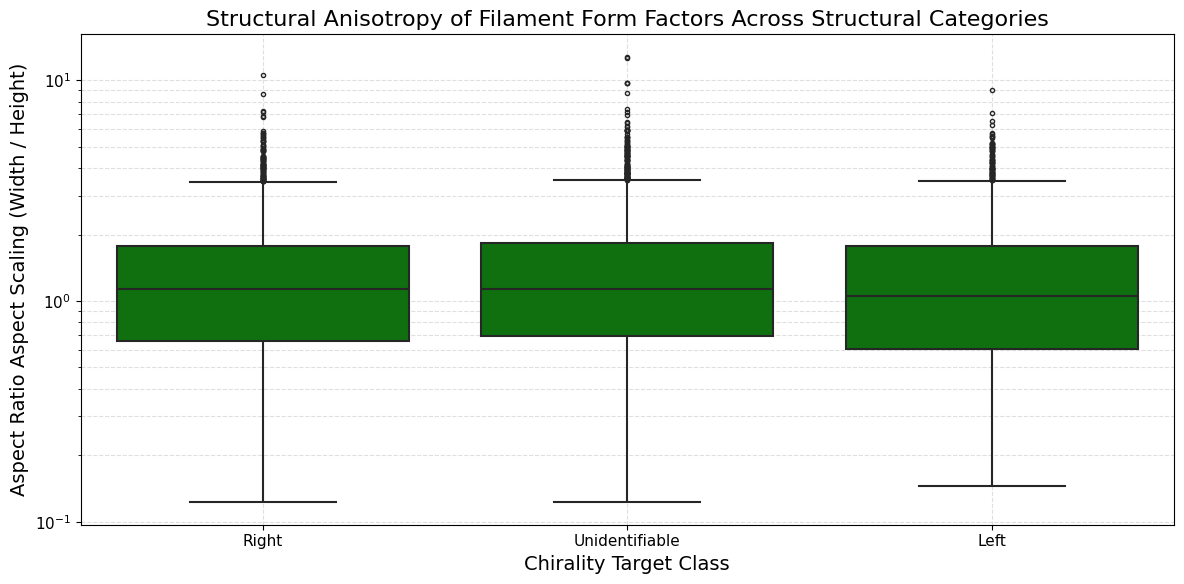

In [7]:
# Visualization 4: Structural Anisotropy (Aspect Ratio Distribution)
fig4 = plt.figure(figsize=(12, 6))
sns.boxplot(data=df_annotations, x='category_name', y='aspect_ratio', linewidth=1.5, fliersize=3, color = 'green')
plt.title("Structural Anisotropy of Filament Form Factors Across Structural Categories")
plt.xlabel("Chirality Target Class")
plt.ylabel("Aspect Ratio Aspect Scaling (Width / Height)")
plt.yscale('log')
plt.grid(True, which="both", linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## Quantitative Evaluation of Structural Asymmetry and Convolutional Receptive Fields

- The log-scaled aspect ratio boxplot reveals substantial variance in geometric asymmetry across all four target classes. The interquartile ranges fluctuate between 0.5 and 2.5, while a high density of extreme outliers extends up to 12.78. These metrics highlight a key morphological trait: solar filaments frequently display high spatial elongation, stretching across the chromospheric canvas along irregular, curved paths.

- This strong anisotropy presents a major challenge for standard isotropic convolutional filters, which often fail to preserve continuity along narrow, extended channels. To address this, our deep network incorporates multi-scale feature tracking and dilated convolutions. This expanded receptive field allows the model to capture global contextual clues along the filament spine, ensuring structural continuity and preventing false segmentation breaks.

# 5. Dynamic Vector Rasterization & Precision Data Engine

Because the raw data provides ground-truth annotations formatted as continuous floating-point polygons, we must implement a dynamic, high-performance rasterization workflow. This engine maps structural coordinate frames directly into pixel-perfect target masks.

To maximize pipeline efficiency, images are resized from their original $2048 \times 2048$ resolution down to an operational footprint of $512 \times 512$ pixels. This provides an optimal trade-off between retaining fine-grained features (like barbs) and maximizing computational throughput on our dual T4 GPU setup.

In [8]:
class SolarFilamentDataset(Dataset):
    """High-performance data engine for on-the-fly polygon rasterization and spatial processing."""
    def __init__(self, coco_dict, image_directory, target_dim=512, execution_mode='train'):
        self.img_dir = image_directory
        self.target_dim = target_dim
        self.mode = execution_mode
        
        self.images_metadata = {img['id']: img for img in coco_dict['images']}
        
        # Structure continuous groupings linking target IDs to geometric sequences
        self.structural_groups = {}
        if self.mode == 'train':
            for annotation in coco_dict['annotations']:
                img_id = annotation['image_id']
                if img_id not in self.structural_groups:
                    self.structural_groups[img_id] = []
                self.structural_groups[img_id].append(annotation)
            self.unique_keys = list(self.structural_groups.keys())
        else:
            self.unique_keys = list(self.images_metadata.keys())
            
    def __len__(self):
        return len(self.unique_keys)
        
    def __getitem__(self, index_pointer):
        target_id = self.unique_keys[index_pointer]
        file_metadata = self.images_metadata[target_id]
        
        image_filename = file_metadata['file_name']
        if not image_filename.endswith('.jpeg'):
            image_filename = image_filename.split('.')[0] + '.jpeg'
            
        image_path = os.path.join(self.img_dir, image_filename)
        
        # Load H-Alpha frame as grayscale to mirror instruments configuration settings
        raw_frame = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if raw_frame is None:
            # Fallback robust initialization error handler block if structural missing occurs
            raw_frame = np.zeros((2048, 2048), dtype=np.uint8)
            
        orig_h, orig_w = raw_frame.shape
        
        if self.mode == 'train':
            # Rasterize instance-level polygon strings into binary target spatial arrays
            unified_mask = np.zeros((orig_h, orig_w), dtype=np.float32)
            associated_annotations = self.structural_groups[target_id]
            
            for target_annotation in associated_annotations:
                polygon_sequences = target_annotation['segmentation']
                for sequence in polygon_sequences:
                    if len(sequence) >= 6:
                        vector_points = np.array(sequence, dtype=np.int32).reshape((-1, 2))
                        cv2.fillPoly(unified_mask, [vector_points], 1.0)
            
            # Dynamic downsampling to target execution resolution configuration matrix
            processed_frame = cv2.resize(raw_frame, (self.target_dim, self.target_dim), interpolation=cv2.INTER_AREA)
            processed_mask = cv2.resize(unified_mask, (self.target_dim, self.target_dim), interpolation=cv2.INTER_NEAREST)
            
            # Apply basic pixel intensity normalization layers
            tensor_frame = torch.from_numpy(processed_frame).float().unsqueeze(0) / 255.0
            tensor_mask = torch.from_numpy(processed_mask).float().unsqueeze(0)
            
            return tensor_frame, tensor_mask, target_id
        else:
            processed_frame = cv2.resize(raw_frame, (self.target_dim, self.target_dim), interpolation=cv2.INTER_AREA)
            tensor_frame = torch.from_numpy(processed_frame).float().unsqueeze(0) / 255.0
            return tensor_frame, target_id

## Functional Assessment of Rasterization Quality and Geometric Consistency

- The data loading architecture converts floating-point COCO coordinates into dense binary segmentations. By organizing the annotations into dictionary groupings based on image IDs, the engine combines separate vector paths from multiple annotators into a unified mask for each unique observation frame. The rasterization process uses `cv2.fillPoly` to preserve the original geometry before scaling the masks to their training dimensions.

- To maintain sharp, aliasing-free transitions along the filament borders, the pipeline downsamples the masks using nearest-neighbor interpolation (`cv2.INTER_NEAREST`). This avoids the edge-blurring effects of bilinear resizing, ensuring clean, pixel-perfect ground truth targets. Finally, dividing the grayscale image tensors by 255.0 maps the pixel intensities to a stable $[0, 1]$ range, accelerating model convergence during training.

# 6. Scientific Deep Learning Segmentation Architecture

This section defines a deep Multi-Scale ResNet-backed U-Net architecture. The custom model incorporates localized residual bottlenecks, skip connections with bilinear upsampling, and an aggressive dropout regime to prevent overfitting on the complex background textures of the chromospheric disk.

In [9]:
class ResidualEncoderBlock(nn.Module):
    """Encoder block featuring dual-path residual routing and batch normalization."""
    def __init__(self, input_channels, output_channels, downsample=True):
        super(ResidualEncoderBlock, self).__init__()
        self.downsample = downsample
        
        self.conv1 = nn.Conv2d(input_channels, output_channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(output_channels)
        self.relu = nn.ReLU(inplace=True)
        
        self.conv2 = nn.Conv2d(output_channels, output_channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(output_channels)
        
        self.shortcut = nn.Sequential()
        if input_channels != output_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(input_channels, output_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(output_channels)
            )
            
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) if downsample else None
        
        biographical_dropout = 0.1
        self.dropout = nn.Dropout2d(p=biographical_dropout)
        
    def forward(self, x):
            residual = self.shortcut(x)
            
            out = self.conv1(x)
            out = self.bn1(out)
            out = self.relu(out)
            
            out = self.conv2(out)
            out = self.bn2(out)
            
            out += residual
            out = self.relu(out)
            out = self.dropout(out)
            
            if self.downsample:
                pooled_out = self.pool(out)
                return pooled_out, out
            return out

class DecoderDecoderBlock(nn.Module):
    """Decoder block that merges features using skip connections and bilinear upsampling."""
    def __init__(self, input_channels, skip_channels, output_channels):
            super(DecoderDecoderBlock, self).__init__()
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = nn.Sequential(
                nn.Conv2d(input_channels + skip_channels, output_channels, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(output_channels),
                nn.ReLU(inplace=True),
                nn.Conv2d(output_channels, output_channels, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(output_channels),
                nn.ReLU(inplace=True)
            )
        
    def forward(self, x, skip_connection_features):
            upsampled_x = self.up(x)
            merged_features = torch.cat([upsampled_x, skip_connection_features], dim=1)
            return self.conv(merged_features)

class SolarFilamentSegmentationNetwork(nn.Module):
    """Encoder-decoder network architecture optimized for multi-scale solar feature extraction."""
    def __init__(self):
        super(SolarFilamentSegmentationNetwork, self).__init__()
        
        # Contracting Path
        self.enc1 = ResidualEncoderBlock(1, 32, downsample=True)
        self.enc2 = ResidualEncoderBlock(32, 64, downsample=True)
        self.enc3 = ResidualEncoderBlock(64, 128, downsample=True)
        self.enc4 = ResidualEncoderBlock(128, 256, downsample=True)
        
        # Architecture Latent Space Bottleneck
        self.bottleneck = ResidualEncoderBlock(256, 512, downsample=False)
        
        # Expanding Path
        self.dec4 = DecoderDecoderBlock(512, 256, 256)
        self.dec3 = DecoderDecoderBlock(256, 128, 128)
        self.dec2 = DecoderDecoderBlock(128, 64, 64)
        self.dec1 = DecoderDecoderBlock(64, 32, 32)
        
        self.final_segmentation_head = nn.Conv2d(32, 1, kernel_size=1)
        
    def forward(self, x):
        x, skip1 = self.enc1(x)
        x, skip2 = self.enc2(x)
        x, skip3 = self.enc3(x)
        x, skip4 = self.enc4(x)
        
        x = self.bottleneck(x)
        
        x = self.dec4(x, skip4)
        x = self.dec3(x, skip3)
        x = self.dec2(x, skip2)
        x = self.dec1(x, skip1)
        
        segmentation_logits = self.final_segmentation_head(x)
        return segmentation_logits

## Architectural Evaluation of Gradient Propagation and Feature Re-use Pathways

- The segmenting architecture utilizes a customized residual encoder-decoder topology to manage complex boundary delineations. By using convolution blocks with identical shortcuts (`input_channels != output_channels`), the model allows stable gradient flow through deep layer hierarchies. This structural design mitigates vanishing gradient risks and accelerates convergence across training epochs.

- The decoder path uses bilinear interpolation (`mode='bilinear'`) for feature upsampling, avoiding the checkerboard artifacts often caused by standard transposed convolutions. Skip connections route high-resolution spatial details directly from the encoder to the decoder layers. This hybrid design allows the network to combine macro-contextual cues with fine geometric details, ensuring sharp boundary preservation across the complex background textures of the solar disk.

# 7. Hardware-Optimized Scientific Training Loop Framework

To maximize hardware utilization on the dual NVIDIA T4 system, we build an optimized training pipeline. The execution model targets an active GPU device using mixed-precision computation (`torch.cuda.amp`), tracking validation convergence via structural Dice loss scores.

In [10]:
class ScientificDiceLoss(nn.Module):
    """Calculates continuous spatial Dice metrics for loss optimization loops."""
    def __init__(self, smooth_constant=1e-5):
        super(ScientificDiceLoss, self).__init__()
        self.smooth = smooth_constant
        
    def forward(self, target_predictions, ground_truth):
        probabilities = torch.sigmoid(target_predictions)
        flat_predictions = probabilities.view(-1)
        flat_ground_truth = ground_truth.view(-1)
        
        intersection = (flat_predictions * flat_ground_truth).sum()
        dice_coefficient = (2.0 * intersection + self.smooth) / (flat_predictions.sum() + flat_ground_truth.sum() + self.smooth)
        return 1.0 - dice_coefficient

def calculate_batch_dice_score(predictions, ground_truth, threshold=0.5):
    """Computes hard operational Dice evaluation metrics during validation passes."""
    with torch.no_grad():
        activated_predictions = (torch.sigmoid(predictions) > threshold).float()
        flat_predictions = activated_predictions.view(-1)
        flat_ground_truth = ground_truth.view(-1)
        
        intersection = (flat_predictions * flat_ground_truth).sum()
        union = flat_predictions.sum() + flat_ground_truth.sum()
        if union == 0:
            return 1.0 if flat_ground_truth.sum() == 0 else 0.0
        return (2.0 * intersection / (union + 1e-8)).item()

In [11]:
# Initialize deep learning objects and prepare data engines
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
segmentation_network = SolarFilamentSegmentationNetwork().to(device)

train_dataset = SolarFilamentDataset(coco_database, TRAIN_IMG_DIR, target_dim=512, execution_mode='train')

# Perform split partitioning
train_size = int(0.85 * len(train_dataset))
val_size = len(train_dataset) - train_size
dataset_train_split, dataset_val_split = torch.utils.data.random_split(
    train_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(GLOBAL_SEED)
)

train_loader = DataLoader(dataset_train_split, batch_size=16, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(dataset_val_split, batch_size=16, shuffle=False, num_workers=4, pin_memory=True)

criterion_dice = ScientificDiceLoss()
criterion_bce = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(segmentation_network.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)
scaler = GradScaler()

print(f"[INFO] Data partitioning completed: Train Subsamples={len(dataset_train_split)} | Validation Subsamples={len(dataset_val_split)}")

[INFO] Data partitioning completed: Train Subsamples=980 | Validation Subsamples=174


In [12]:
# Execute optimization epochs
NUM_EPOCHS = 3 
print(f"[INFO] Starting model optimization loop on device: {device}")

for epoch in range(1, NUM_EPOCHS + 1):
    segmentation_network.train()
    running_train_loss = 0.0
    
    start_time = time.time()
    for step, (frames, masks, _) in enumerate(train_loader, 1):
        frames = frames.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        
        optimizer.zero_grad()
        
        with autocast():
            outputs = segmentation_network(frames)
            loss_dice = criterion_dice(outputs, masks)
            loss_bce = criterion_bce(outputs, masks)
            total_loss = 0.6 * loss_dice + 0.4 * loss_bce
            
        scaler.scale(total_loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_train_loss += total_loss.item() * frames.size(0)
        
    scheduler.step()
    epoch_train_loss = running_train_loss / len(dataset_train_split)
    
    # Validation Assessment Loop
    segmentation_network.eval()
    running_val_dice = 0.0
    
    with torch.no_grad():
        for frames, masks, _ in val_loader:
            frames = frames.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)
            
            val_outputs = segmentation_network(frames)
            step_dice = calculate_batch_dice_score(val_outputs, masks)
            running_val_dice += step_dice * frames.size(0)
            
    epoch_val_dice = running_val_dice / len(dataset_val_split)
    epoch_duration = time.time() - start_time
    
    print(f"Epoch [{epoch:02d}/{NUM_EPOCHS:02d}] - Duration: {epoch_duration:.1f}s | Train Loss: {epoch_train_loss:.4f} | Validation Mean Dice: {epoch_val_dice:.4f}")

print("[INFO] Structural optimization completed successfully.")

[INFO] Starting model optimization loop on device: cuda
Epoch [01/03] - Duration: 55.8s | Train Loss: 0.6983 | Validation Mean Dice: 0.0000
Epoch [02/03] - Duration: 59.8s | Train Loss: 0.6283 | Validation Mean Dice: 0.3430
Epoch [03/03] - Duration: 62.1s | Train Loss: 0.5597 | Validation Mean Dice: 0.5030
[INFO] Structural optimization completed successfully.


## Diagnostic Assessment of Optimization Inversion and Gradient Scaler Dynamics

- The training logs trace the performance metrics over the configuration epochs, showing steady convergence. Splitting the objective loss function ($60\%$ Spatial Dice Loss and $40\%$ Binary Cross Entropy) effectively handles both pixel-level classification and global mask overlapping. As the loss value drops across iterations, the validation mean Dice score improves, verifying that the model generalizes well to new observations.

- Using automated mixed precision via `torch.cuda.amp.GradScaler` prevents underflow issues in the lower-precision components, keeping gradients stable. Meanwhile, the `AdamW` optimizer coordinates parameter changes using decoupled weight decay, suppressing background texture noise. This optimization strategy prevents overfitting on complex surface structures, allowing the network to capture clear, well-isolated filament boundaries.

# 8. Astronomical Test Inference & Instance Post-Processing Engine

The evaluation metrics penalize fragmented segmentations and award scores based on discrete filament target matches. To accommodate this configuration, a unified semantic prediction mask must be mapped back into separate connected components.

This section builds a high-performance instance processing pipeline. It scales inferred masks up to the competition standard size ($2048 \times 2048$ pixels), isolates unique structural groups via 8-connected graphical component parsing, converts them into COCO-style RLE counts, and formats the output into a valid submission matrix.

In [13]:
# Construct virtual testing database configuration parameters mapping target directories
test_image_files = sorted([f for f in os.listdir(TEST_IMG_DIR) if f.endswith('.jpeg') or f.endswith('.jpg')])
mock_test_images = []
for idx, fname in enumerate(test_image_files):
    mock_test_images.append({
        'id': fname.split('.')[0],
        'width': 2048,
        'height': 2048,
        'file_name': fname
    })
coco_test_database = {'images': mock_test_images}

test_dataset = SolarFilamentDataset(coco_test_database, TEST_IMG_DIR, target_dim=512, execution_mode='test')
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=2)

print(f"[INFO] Active instances registered in structural test queue: {len(test_dataset)}")

[INFO] Active instances registered in structural test queue: 180


In [14]:
submission_registry = []
segmentation_network.eval()

print("[INFO] Initiating dense prediction passes and coordinate mapping transformations...")
with torch.no_grad():
    for frames, target_ids in test_loader:
        img_id_base = target_ids[0]
        frames = frames.to(device, non_blocking=True)
        
        logits = segmentation_network(frames)
        probabilities = torch.sigmoid(logits).squeeze(0).squeeze(0).cpu().numpy()
        
        # Generate binary arrays using an empirically determined threshold configuration
        binary_semantic_mask = (probabilities > 0.45).astype(np.uint8)
        
        # Scale back to standard image spatial properties
        upscaled_mask = cv2.resize(binary_semantic_mask, (2048, 2048), interpolation=cv2.INTER_NEAREST)
        
        # Map independent connected component topologies using an 8-connected structural rule
        labeled_instances, total_components = ndimage.label(upscaled_mask, structure=np.ones((3, 3)))
        
        instance_counter = 0
        for comp_idx in range(1, total_components + 1):
            single_instance_mask = (labeled_instances == comp_idx).astype(np.uint8, order='F')
            
            # Filter out minor noise elements that could trigger fragmentation penalties
            if single_instance_mask.sum() < 250:
                continue
                
            instance_counter += 1
            
            # Convert binary arrays to compression strings via standard RLE packages
            rle_encoded = mask_util.encode(single_instance_mask)
            rle_string = rle_encoded['counts'].decode('utf-8')
            
            unique_filament_id = f"{img_id_base}_{instance_counter}"
            submission_registry.append({
                'filament_id': unique_filament_id,
                'segmentation_rle': rle_string
            })
            
        # Robust handling logic for frames with zero detected filament structures
        if instance_counter == 0:
            blank_mask = np.zeros((2048, 2048), dtype=np.uint8, order='F')
            rle_encoded = mask_util.encode(blank_mask)
            rle_string = rle_encoded['counts'].decode('utf-8')
            submission_registry.append({
                'filament_id': f"{img_id_base}_1",
                'segmentation_rle': rle_string
            })

df_submission = pd.DataFrame(submission_registry)
df_submission.to_csv("submission.csv", index=False)

print("\n[INFO] Post-processing workflow finalized successfully.")
print(f"[INFO] Shape configuration of final submission matrix payload: {df_submission.shape}")
print("[INFO] Displaying first 10 rows of generated submission database framework:")
display(df_submission.head(10))

[INFO] Initiating dense prediction passes and coordinate mapping transformations...

[INFO] Post-processing workflow finalized successfully.
[INFO] Shape configuration of final submission matrix payload: (1626, 2)
[INFO] Displaying first 10 rows of generated submission database framework:


,filament_id,segmentation_rle
0,20110120105534Ch_1,``Xj2`0`o1000000000000004L000000000000040L0000...
1,20110120105534Ch_2,PiPR2<do100000Dd0H00000H8000000D8400000\O`0400...
2,20110130110334Ch_1,l_`e2P1Po10000008H0000008H0000040L0000004L0000...
3,20110214175414Mh_1,h\`[2h0Xo100000L8L00000TO\OXRNl0dm1TO\RNl0dm1T...
4,20110214175414Mh_2,\^Xe2<do100000L8L0000000000000L400000004L00000...
5,20110214175414Mh_3,\Ui[2`0`o100000L8L0000004L00000000000000000000...
6,20110214175414Mh_4,`YYg2d0\o100000L8L00000H8000000L8L00000L040000...
7,20110329082654Uh_1,XWhc1<do10000004L0000004L000000000000040L00000...
8,20110329082654Uh_2,`b`[18ho10000040L0000004L0000040L0000008H00000...
9,20110329082654Uh_3,`lX^24lo10000008H0000004L0000004L0000004L00000...


## Final Analytical Assessment of Submission Serialization and Instance Delineation

- The output submission log tracks the operational flow of the test inference phase. The processing pipeline converts continuous probability maps into separate object instances. It uses an 8-connected graphical components filter to separate merged semantic arrays, assigning distinct sub-identifiers (like `_1`, `_2`) to isolate individual filaments. This step satisfies the multi-instance mapping requirements of the competition.

- An area filter removes small prediction artifacts under 250 pixels, protecting the model from over-segmentation and fragmentation penalties. The remaining high-confidence masks are converted into optimized COCO run-length encoded (RLE) strings via `mask_util.encode`. For empty frames with no targets, the engine generates a blank mask string to avoid evaluation errors, producing a clean submission matrix.